In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [3]:
df=pd.read_csv(r"C:\Users\anant\Desktop\abalone.csv")

In [9]:
df.head()

,Type,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [11]:
print("Shape of dataset:", df.shape)

Shape of dataset: (4177, 9)


In [13]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Type             0
LongestShell     0
Diameter         0
Height           0
WholeWeight      0
ShuckedWeight    0
VisceraWeight    0
ShellWeight      0
Rings            0
dtype: int64


In [15]:
print("\n--- Statistical Summary ---")
print(df.describe(include='all'))


--- Statistical Summary ---
        Type  LongestShell     Diameter       Height  WholeWeight  \
count   4177   4177.000000  4177.000000  4177.000000  4177.000000   
unique     3           NaN          NaN          NaN          NaN   
top        M           NaN          NaN          NaN          NaN   
freq    1528           NaN          NaN          NaN          NaN   
mean     NaN      0.523992     0.407881     0.139516     0.828742   
std      NaN      0.120093     0.099240     0.041827     0.490389   
min      NaN      0.075000     0.055000     0.000000     0.002000   
25%      NaN      0.450000     0.350000     0.115000     0.441500   
50%      NaN      0.545000     0.425000     0.140000     0.799500   
75%      NaN      0.615000     0.480000     0.165000     1.153000   
max      NaN      0.815000     0.650000     1.130000     2.825500   

        ShuckedWeight  VisceraWeight  ShellWeight        Rings  
count     4177.000000    4177.000000  4177.000000  4177.000000  
unique      

In [23]:
#encoding
if 'Type' in df.columns:
    le = LabelEncoder()
    df['Type'] = le.fit_transform(df['Type'])


In [25]:
df.head()

,Type,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


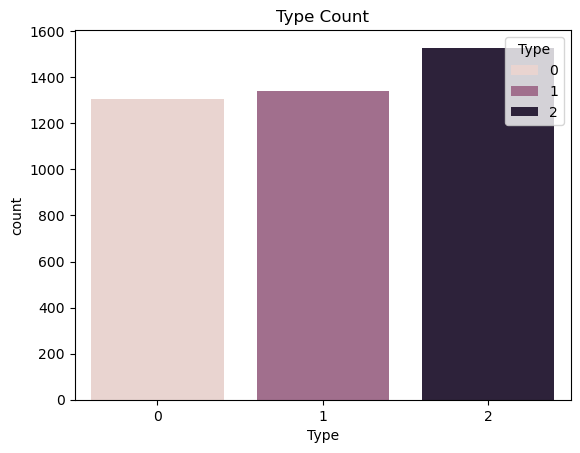

In [49]:
# Countplot for target
if 'Type' in df.columns:
    sns.countplot(data=df, x='Type',hue='Type')
    plt.title("Type Count")
    plt.show()

In [63]:
#here male is lightely dominating over the female and infant

In [41]:
# Compute correlation of each feature with the target
feature_target_corr = df.corr()['Type'].sort_values(ascending=False)

print("Correlation of features with target:")
print(feature_target_corr)

Correlation of features with target:
Type             1.000000
ShuckedWeight   -0.001373
WholeWeight     -0.021391
VisceraWeight   -0.032067
Rings           -0.034627
ShellWeight     -0.034854
LongestShell    -0.036066
Diameter        -0.038874
Height          -0.042077
Name: Type, dtype: float64


In [57]:
#correlation is very less

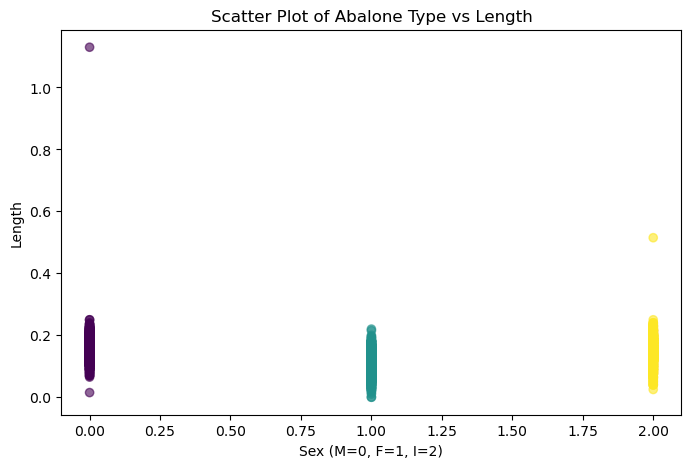

In [47]:
# Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['Type'], df['Height'], alpha=0.6, c=df['Type'], cmap='viridis')
plt.title('Scatter Plot of Abalone Type vs Length')
plt.xlabel('Sex (M=0, F=1, I=2)')
plt.ylabel('Length')
plt.show()

In [51]:
#this shows there is a correlation error

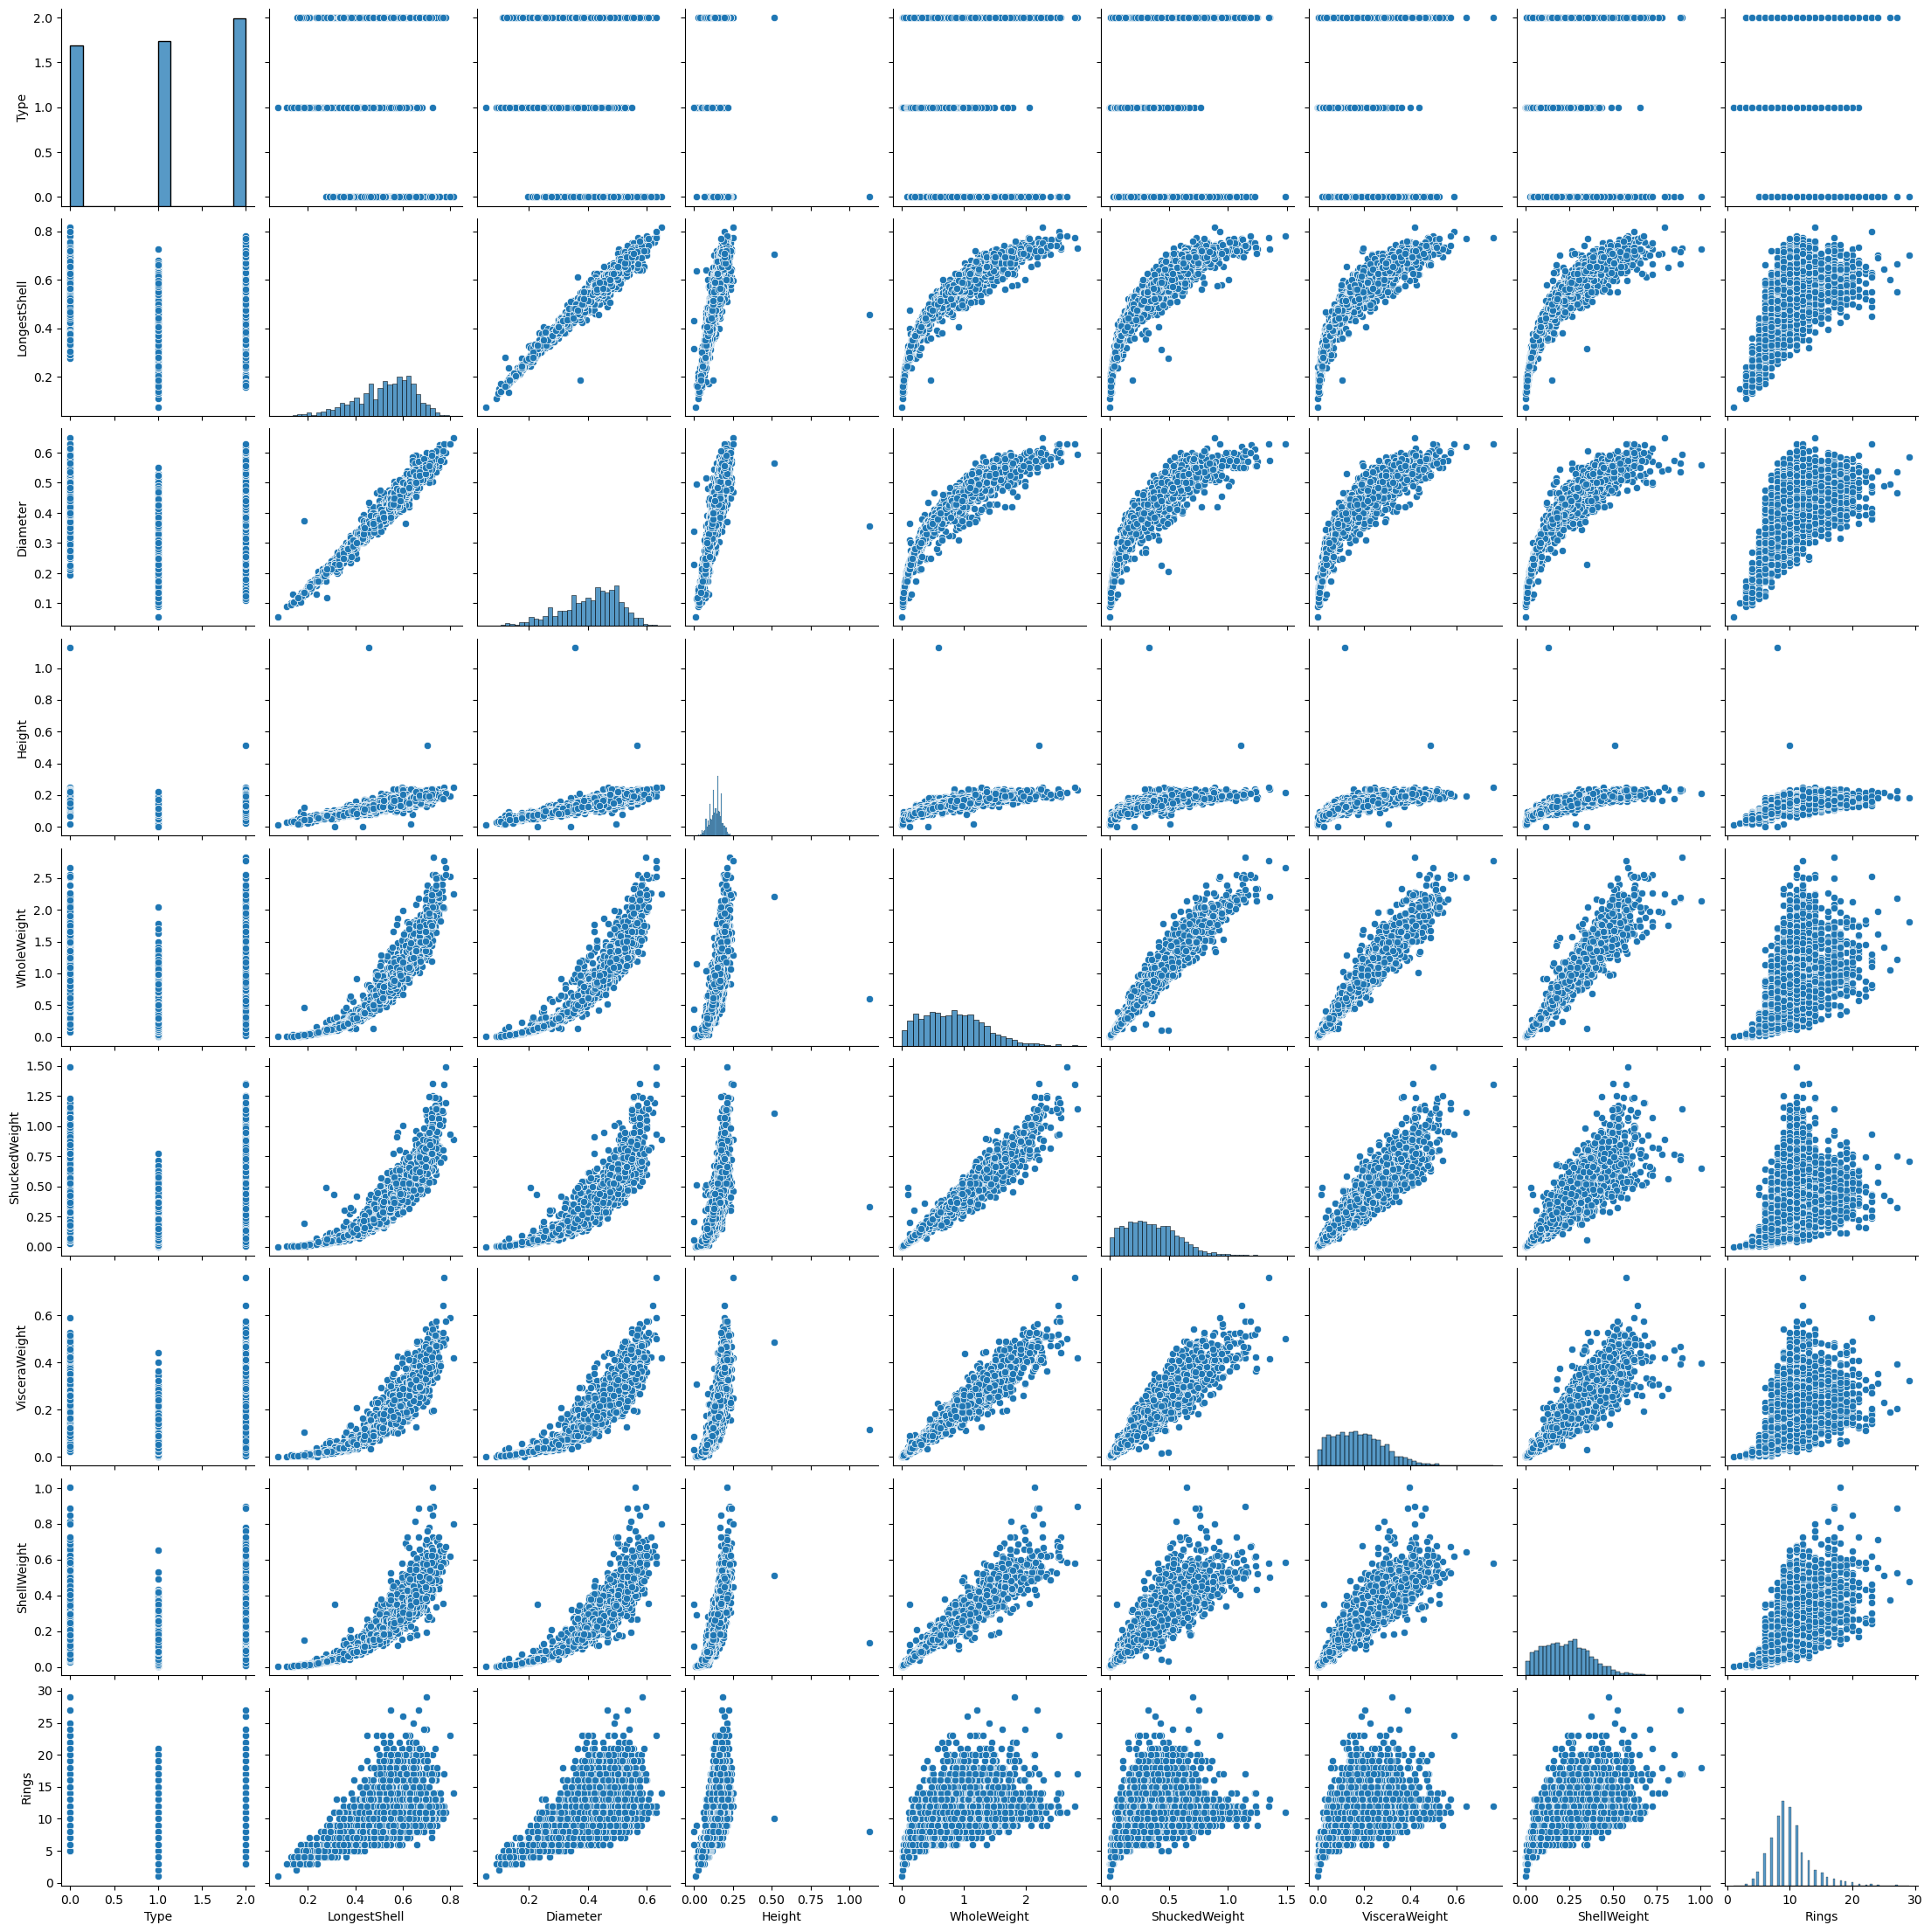

In [55]:
sns.pairplot(df)
plt.show()

In [69]:
#here the more amount of data is nonlinear so spearman correlation is applied
feature_target_corr = df.corr(method='spearman')['Type'].sort_values(ascending=False)

print("Correlation of features with target:")
print(feature_target_corr)

Correlation of features with target:
Type             1.000000
ShuckedWeight   -0.000023
WholeWeight     -0.013197
Rings           -0.020349
ShellWeight     -0.020913
LongestShell    -0.021516
VisceraWeight   -0.021652
Diameter        -0.022653
Height          -0.029176
Name: Type, dtype: float64


In [61]:
#very less correlation

In [67]:
#here the target variable(Type)is a multiclass

In [73]:
#spliting the x and y values dependent and independent

In [75]:
# Independent variables (features)
X = df[['LongestShell', 'Diameter', 'Height', 
        'WholeWeight', 'ShuckedWeight', 
        'VisceraWeight', 'ShellWeight', 'Rings']]

# Dependent variable (target)
y = df['Type']


In [77]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [104]:
model = LogisticRegression(multi_class='ovr',solver='lbfgs',max_iter=1000,random_state=42)


In [106]:
# Creatig stratified k-fold cross-validation
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [108]:
# Performing stratified k-fold cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="accuracy")

# Prining CV scores
print("CV scores:", cv_scores)

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CV scores: [0.54066986 0.55023923 0.57125749 0.53173653 0.57964072]


C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [94]:
 # Cross-Validation Evaluation
scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='accuracy')

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

In [96]:
#Results
print("Cross-validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation Accuracy Scores: [0.54425837 0.55382775 0.57245509 0.53652695 0.58802395]
Mean Accuracy: 0.5590184224851733


In [98]:
#Evaluate Model
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nTest Accuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


NameError: name 'y_test' is not defined